<a href="https://www.kaggle.com/code/omborse771924/messy-e-commerce-sales-data-eda?scriptVersionId=346107995" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kandeeldev/messy-e-commerce-sales-data/messy_ecommerce_sales_data.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/kandeeldev/messy-e-commerce-sales-data/messy_ecommerce_sales_data.csv')

In [3]:
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


In [4]:
df.tail()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
98,198,Customer_198,ORD-14608,7/27/2025,Vacuum,NaN,2,497.01,Cash on Delivery,Shipped,994.020
99,199,Customer_199,ORD-82922,1/22/2025,Blender,Home,5,372.28,Credit Card,Shipped,1861.400
100,175,Customer_175,ORD-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,77.952
101,142,Customer_142,ORD-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.300
102,146,Customer_146,ORD-32755,7/9/2025,Basketball,electronic,2,705.42,Bank Transfer,Processing,1410.840


In [5]:
df.info

<bound method DataFrame.info of       ID  Customer_Name   Order_ID  Order_Date        Product     Category  \
0    100   Customer_100  ORD-41285  11/22/2024        Blender         Home   
1    101   Customer_101  ORD-35783    7/5/2025     Smartphone  Electronics   
2    102   Customer_102  ORD-84355  12/23/2024  Tennis Racket       Sports   
3    103   Customer_103  ORD-57811   3/19/2025        Science        Books   
4    104   Customer_104  ORD-93614  10/20/2025      Biography        Books   
..   ...            ...        ...         ...            ...          ...   
98   198   Customer_198  ORD-14608   7/27/2025         Vacuum          NaN   
99   199   Customer_199  ORD-82922   1/22/2025        Blender         Home   
100  175   Customer_175  ORD-56651   2/24/2025     Headphones  Electronics   
101  142   Customer_142  ORD-69018  10/30/2025          Shoes     Clothing   
102  146   Customer_146  ORD-32755    7/9/2025     Basketball   electronic   

    Quantity   Price    Payment

In [6]:
df.describe

<bound method NDFrame.describe of       ID  Customer_Name   Order_ID  Order_Date        Product     Category  \
0    100   Customer_100  ORD-41285  11/22/2024        Blender         Home   
1    101   Customer_101  ORD-35783    7/5/2025     Smartphone  Electronics   
2    102   Customer_102  ORD-84355  12/23/2024  Tennis Racket       Sports   
3    103   Customer_103  ORD-57811   3/19/2025        Science        Books   
4    104   Customer_104  ORD-93614  10/20/2025      Biography        Books   
..   ...            ...        ...         ...            ...          ...   
98   198   Customer_198  ORD-14608   7/27/2025         Vacuum          NaN   
99   199   Customer_199  ORD-82922   1/22/2025        Blender         Home   
100  175   Customer_175  ORD-56651   2/24/2025     Headphones  Electronics   
101  142   Customer_142  ORD-69018  10/30/2025          Shoes     Clothing   
102  146   Customer_146  ORD-32755    7/9/2025     Basketball   electronic   

    Quantity   Price    Payme

In [7]:
df.isnull

<bound method DataFrame.isnull of       ID  Customer_Name   Order_ID  Order_Date        Product     Category  \
0    100   Customer_100  ORD-41285  11/22/2024        Blender         Home   
1    101   Customer_101  ORD-35783    7/5/2025     Smartphone  Electronics   
2    102   Customer_102  ORD-84355  12/23/2024  Tennis Racket       Sports   
3    103   Customer_103  ORD-57811   3/19/2025        Science        Books   
4    104   Customer_104  ORD-93614  10/20/2025      Biography        Books   
..   ...            ...        ...         ...            ...          ...   
98   198   Customer_198  ORD-14608   7/27/2025         Vacuum          NaN   
99   199   Customer_199  ORD-82922   1/22/2025        Blender         Home   
100  175   Customer_175  ORD-56651   2/24/2025     Headphones  Electronics   
101  142   Customer_142  ORD-69018  10/30/2025          Shoes     Clothing   
102  146   Customer_146  ORD-32755    7/9/2025     Basketball   electronic   

    Quantity   Price    Payme

In [8]:
df.isnull().sum()

ID                 0
 Customer_Name     0
Order_ID           0
Order_Date         0
Product            0
 Category          8
Quantity           5
Price              5
Payment_Method     0
Status             0
Total             14
dtype: int64

In [9]:
df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity           object
Price              object
Payment_Method     object
Status             object
Total             float64
dtype: object

In [10]:
df['Total'] = df['Total'].fillna(df['Total'].median())
df

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.000
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,1138.760
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.050
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.600
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.510
...,...,...,...,...,...,...,...,...,...,...,...
98,198,Customer_198,ORD-14608,7/27/2025,Vacuum,NaN,2,497.01,Cash on Delivery,Shipped,994.020
99,199,Customer_199,ORD-82922,1/22/2025,Blender,Home,5,372.28,Credit Card,Shipped,1861.400
100,175,Customer_175,ORD-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,77.952
101,142,Customer_142,ORD-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.300


In [11]:
df.isnull().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
Product           0
 Category         8
Quantity          5
Price             5
Payment_Method    0
Status            0
Total             0
dtype: int64

In [12]:
# ==========================================================
# HANDLE NULL VALUES + CONVERT NUMERIC COLUMNS
# ==========================================================

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# ----------------------------------------------------------
# 1. NULL VALUES BEFORE
# ----------------------------------------------------------

print("=" * 60)
print("NULL VALUES BEFORE")
print("=" * 60)

print(df.isnull().sum())


# ----------------------------------------------------------
# 2. CONVERT NUMERIC COLUMNS TO NUMERIC DATA TYPE
# ----------------------------------------------------------

df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

df["Total"] = pd.to_numeric(
    df["Total"],
    errors="coerce"
)


# ----------------------------------------------------------
# 3. HANDLE CATEGORY NULL VALUES
# ----------------------------------------------------------

df["Category"] = df["Category"].fillna(
    "Unknown"
)


# ----------------------------------------------------------
# 4. HANDLE QUANTITY NULL VALUES
# ----------------------------------------------------------

quantity_median = df["Quantity"].median()

df["Quantity"] = df["Quantity"].fillna(
    quantity_median
)


# ----------------------------------------------------------
# 5. HANDLE PRICE NULL VALUES
# ----------------------------------------------------------

price_median = df["Price"].median()

df["Price"] = df["Price"].fillna(
    price_median
)


# ----------------------------------------------------------
# 6. HANDLE TOTAL NULL VALUES
# ----------------------------------------------------------

total_median = df["Total"].median()

df["Total"] = df["Total"].fillna(
    total_median
)


# ----------------------------------------------------------
# 7. FINAL NULL CHECK
# ----------------------------------------------------------

print("\n" + "=" * 60)
print("NULL VALUES AFTER HANDLING")
print("=" * 60)

print(df.isnull().sum())


# ----------------------------------------------------------
# 8. CHECK DATA TYPES
# ----------------------------------------------------------

print("\n" + "=" * 60)
print("DATA TYPES AFTER CONVERSION")
print("=" * 60)

print(df.dtypes)


# ----------------------------------------------------------
# 9. DISPLAY CLEANED DATA
# ----------------------------------------------------------

print("\n" + "=" * 60)
print("CLEANED DATA")
print("=" * 60)

print(df.head())

NULL VALUES BEFORE
ID                0
Customer_Name     0
Order_ID          0
Order_Date        0
Product           0
Category          8
Quantity          5
Price             5
Payment_Method    0
Status            0
Total             0
dtype: int64

NULL VALUES AFTER HANDLING
ID                0
Customer_Name     0
Order_ID          0
Order_Date        0
Product           0
Category          0
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

DATA TYPES AFTER CONVERSION
ID                  int64
Customer_Name      object
Order_ID           object
Order_Date         object
Product            object
Category           object
Quantity          float64
Price             float64
Payment_Method     object
Status             object
Total             float64
dtype: object

CLEANED DATA
    ID Customer_Name   Order_ID  Order_Date        Product     Category  \
0  100  Customer_100  ORD-41285  11/22/2024        Blender         Ho

In [13]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
98     False
99     False
100    False
101    False
102     True
Length: 103, dtype: bool

In [14]:
df.duplicated().sum()

np.int64(1)

In [15]:
df.columns

Index(['ID', 'Customer_Name', 'Order_ID', 'Order_Date', 'Product', 'Category',
       'Quantity', 'Price', 'Payment_Method', 'Status', 'Total'],
      dtype='object')

## EDA

Columns:
['ID', 'Customer_Name', 'Order_ID', 'Order_Date', 'Product', 'Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total']

DATASET SHAPE
(103, 11)

DATA TYPES
ID                  int64
Customer_Name      object
Order_ID           object
Order_Date         object
Product            object
Category           object
Quantity          float64
Price             float64
Payment_Method     object
Status             object
Total             float64
dtype: object

SUMMARY STATISTICS
                ID Customer_Name   Order_ID Order_Date  Product Category  \
count   103.000000           103        103        103      103      103   
unique         NaN           100        100         86       21       10   
top            NaN  Customer_146  ORD-32755   2/9/2025  Blender    Books   
freq           NaN             2          2          4        8       22   
mean    149.640777           NaN        NaN        NaN      NaN      NaN   
std      28.704326           NaN        NaN    

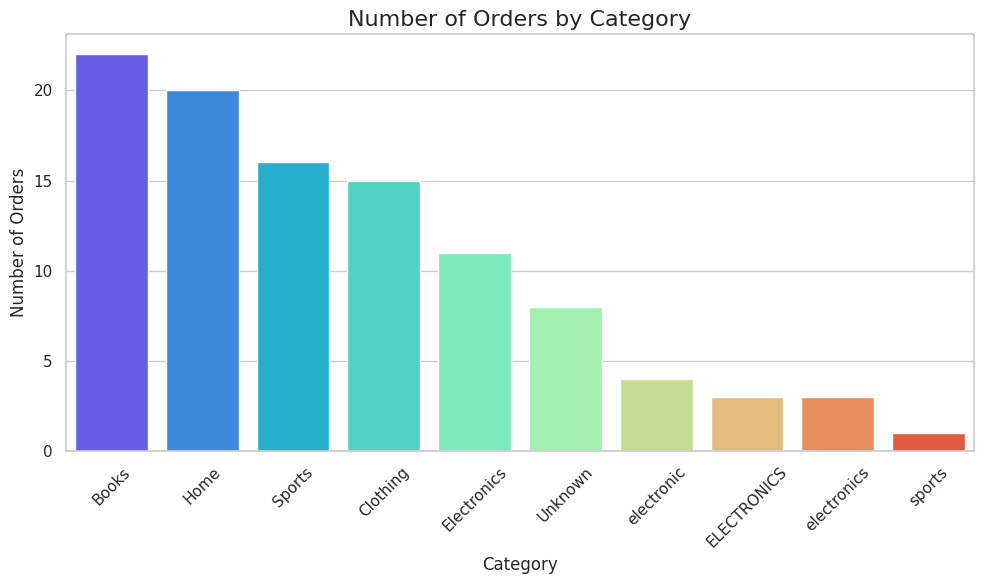

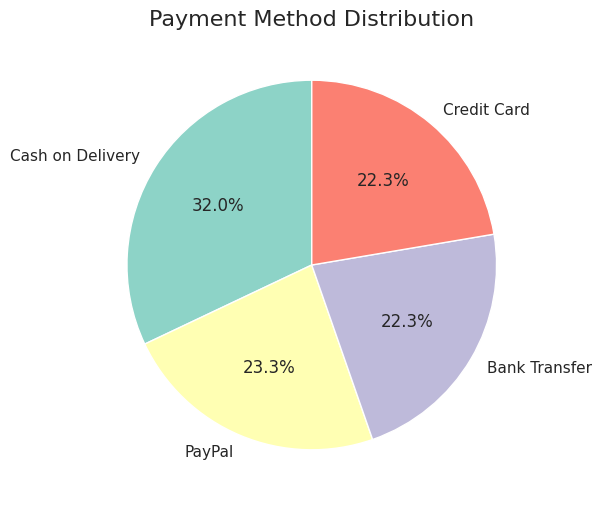

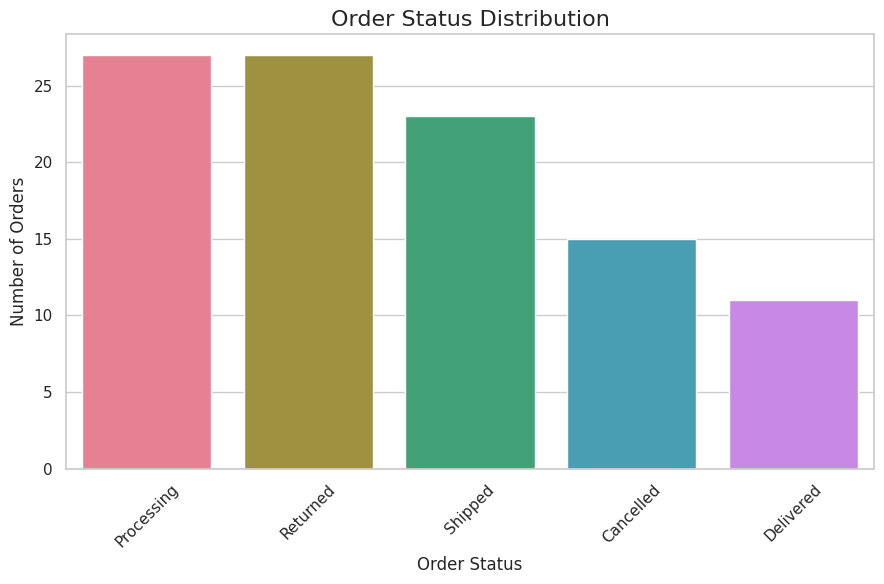

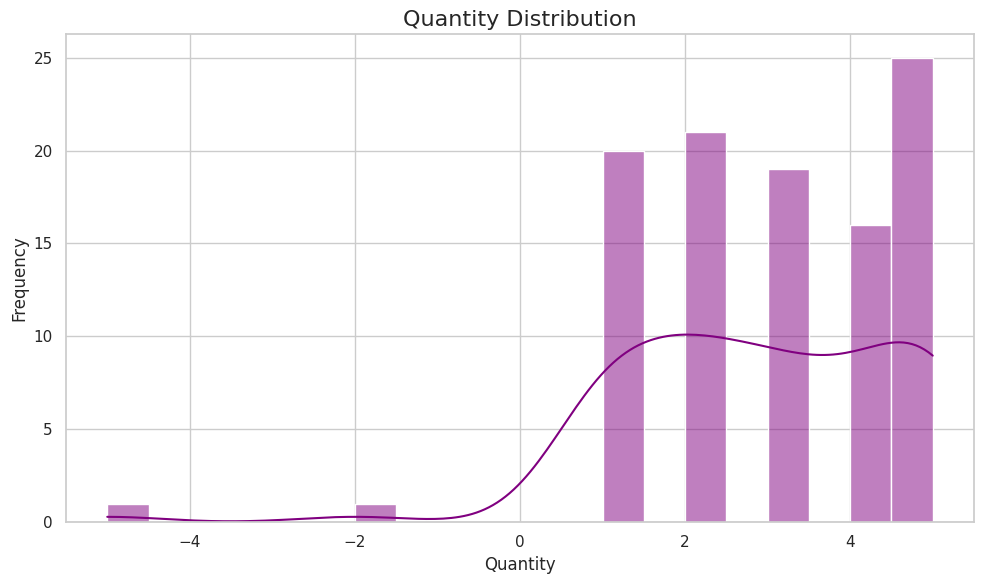

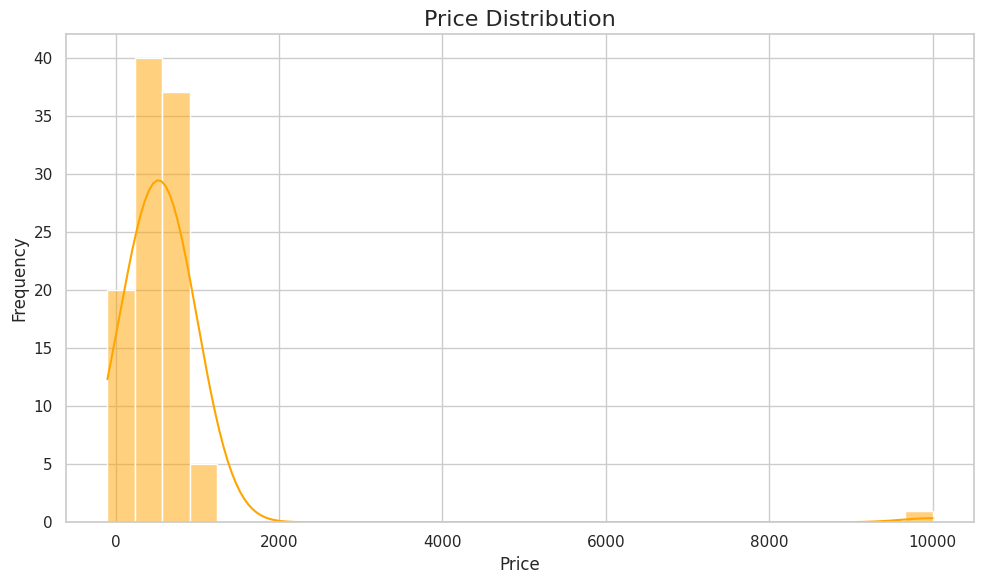

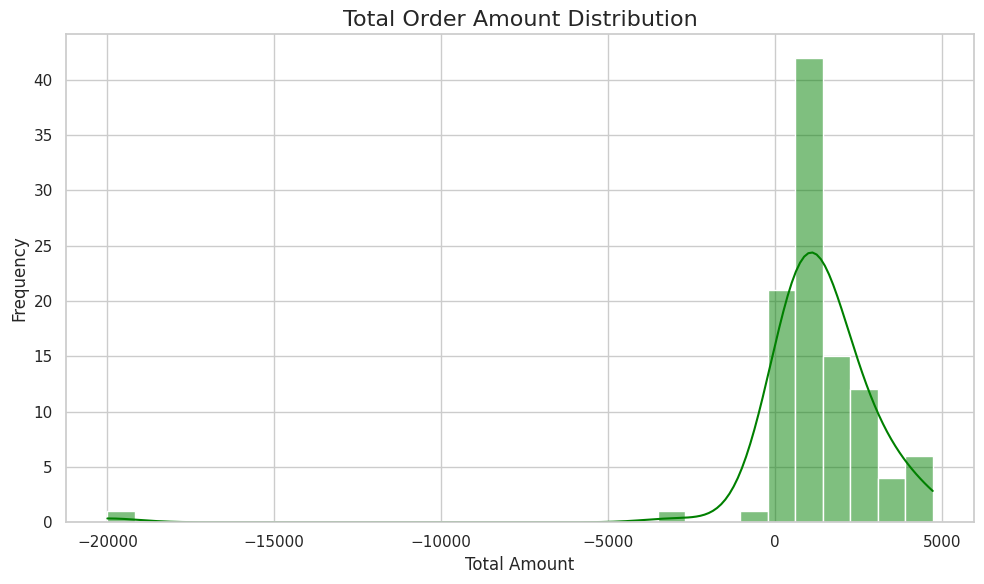

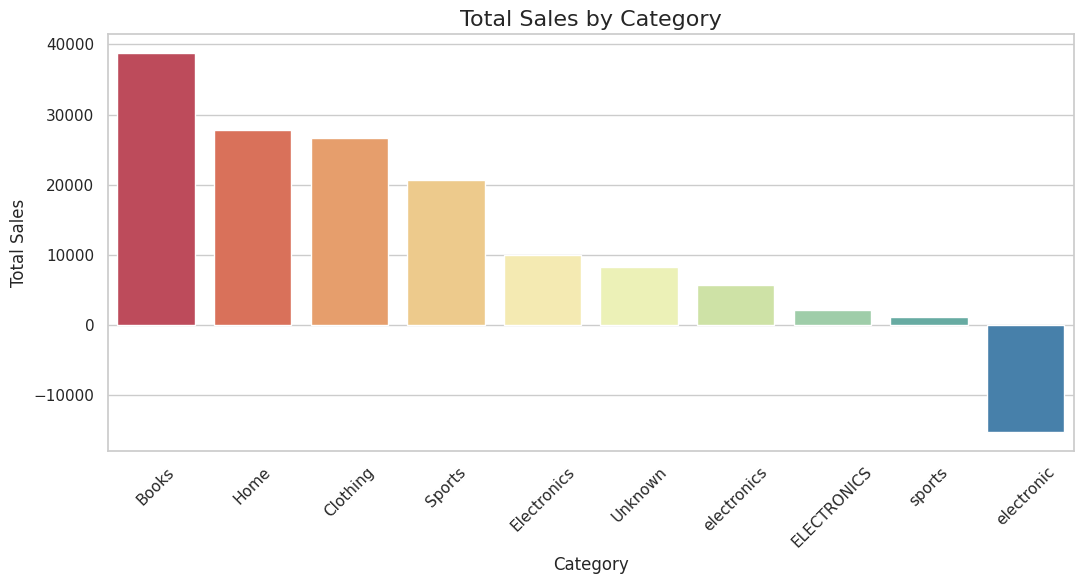

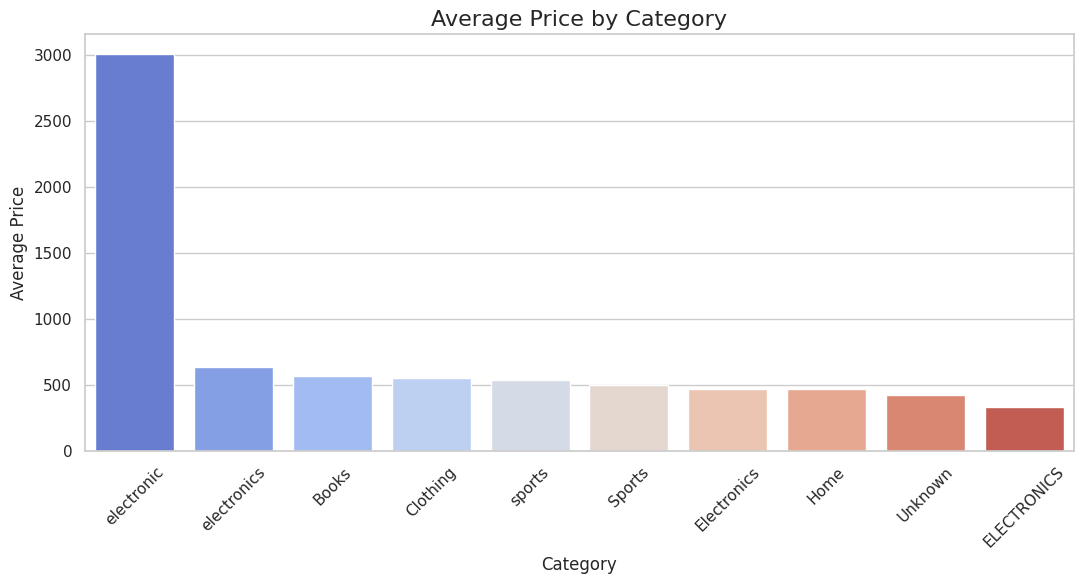

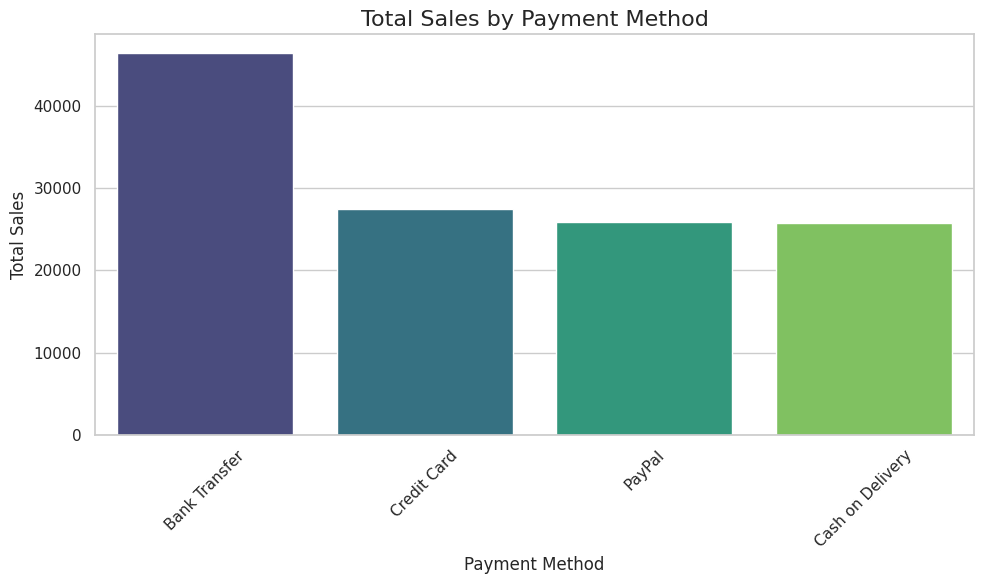

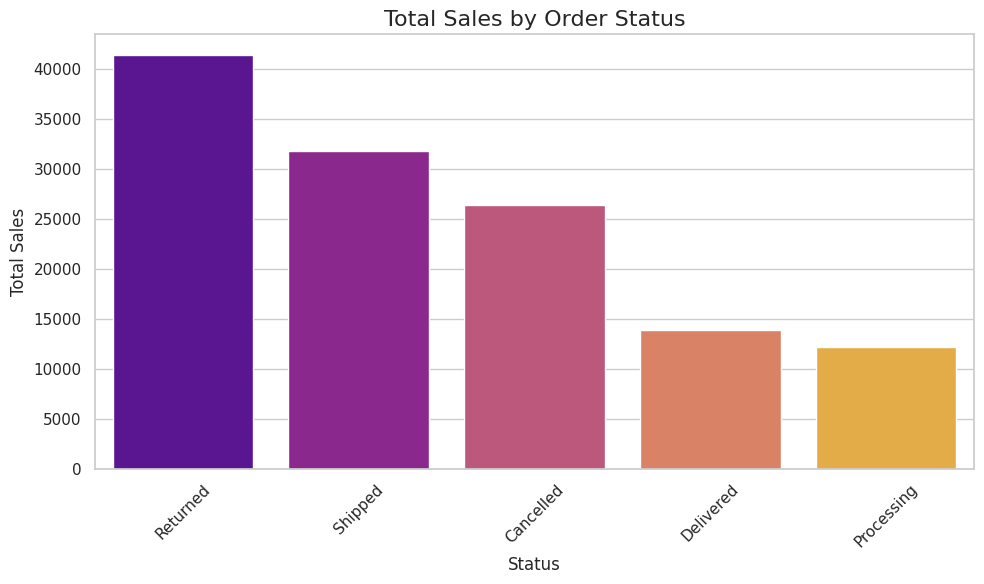

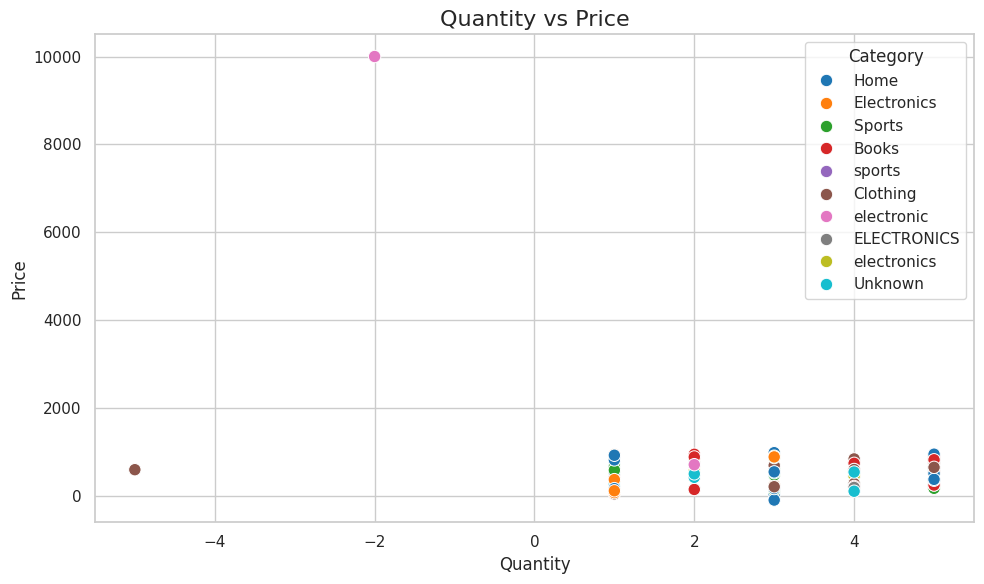

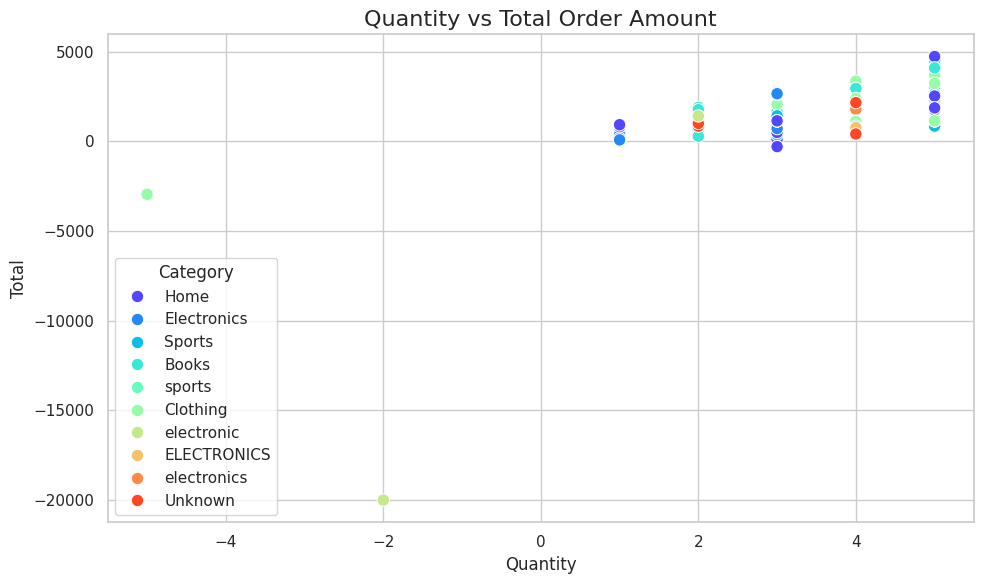

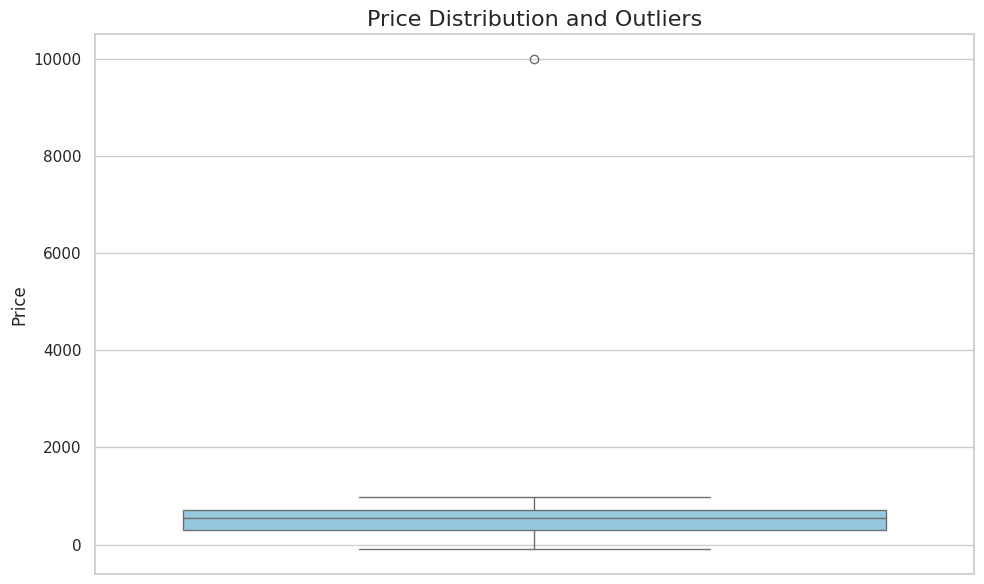

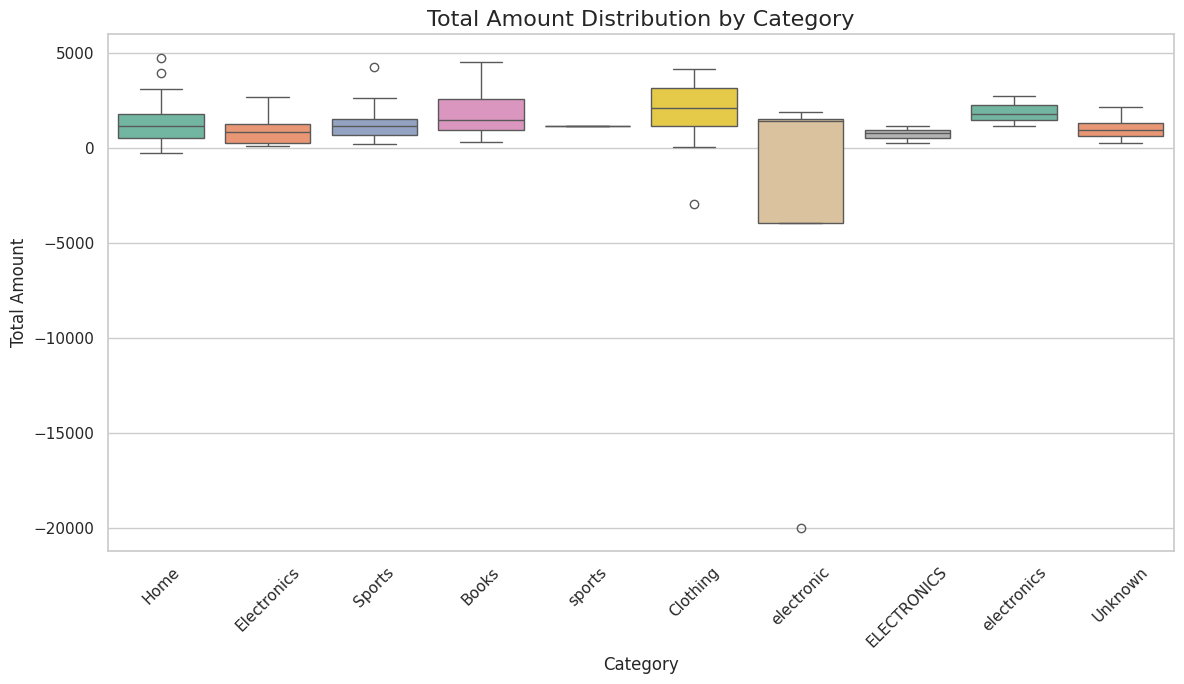

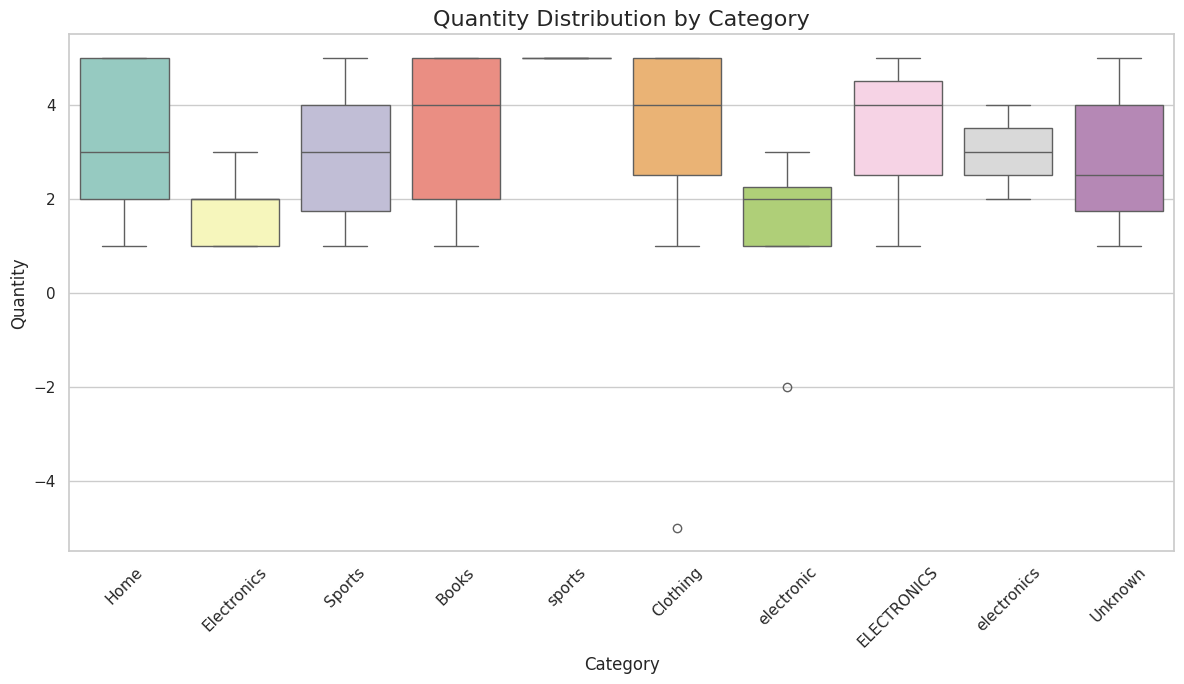

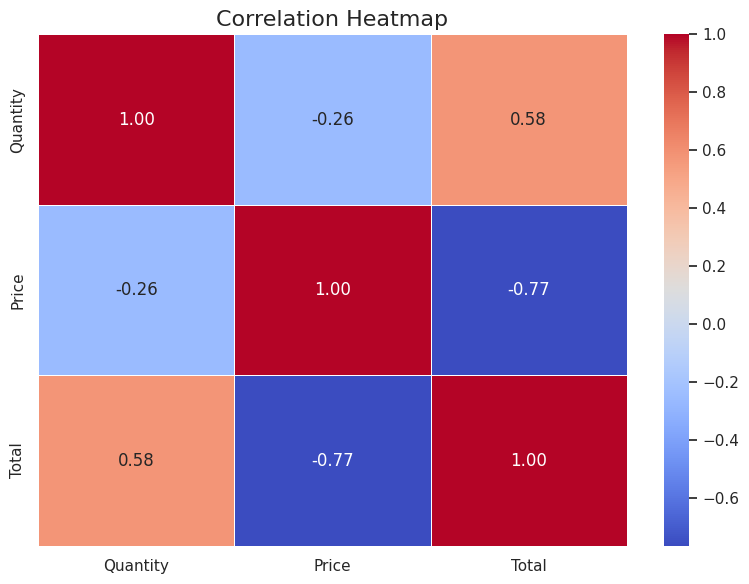

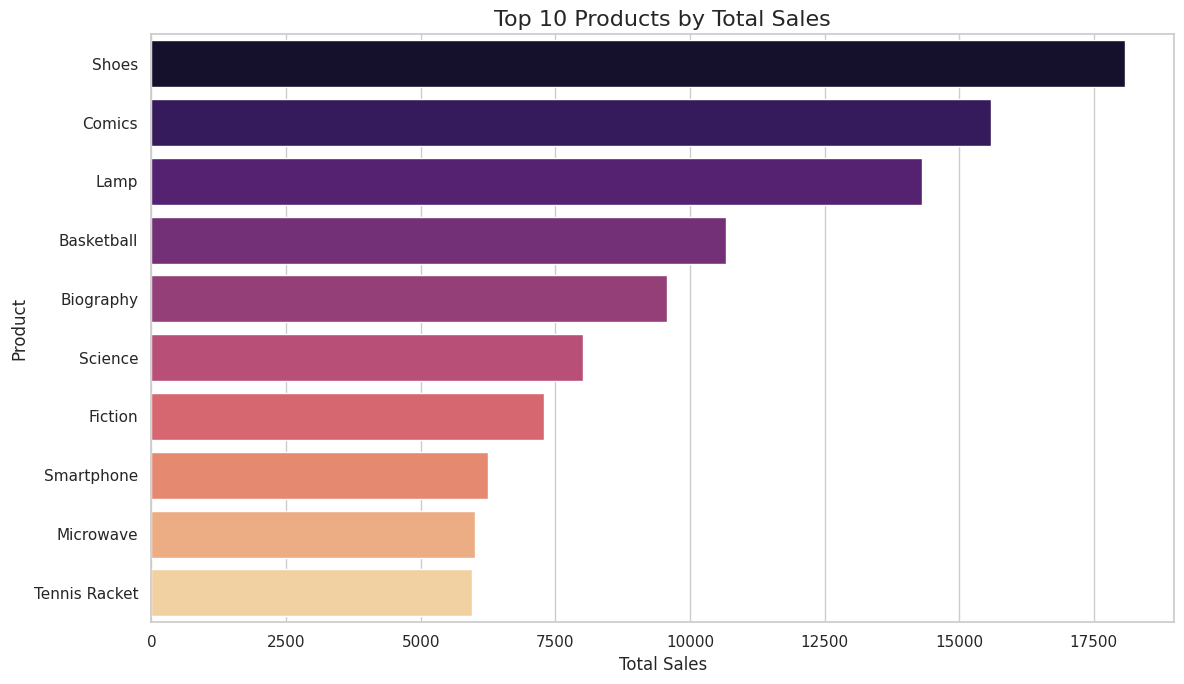

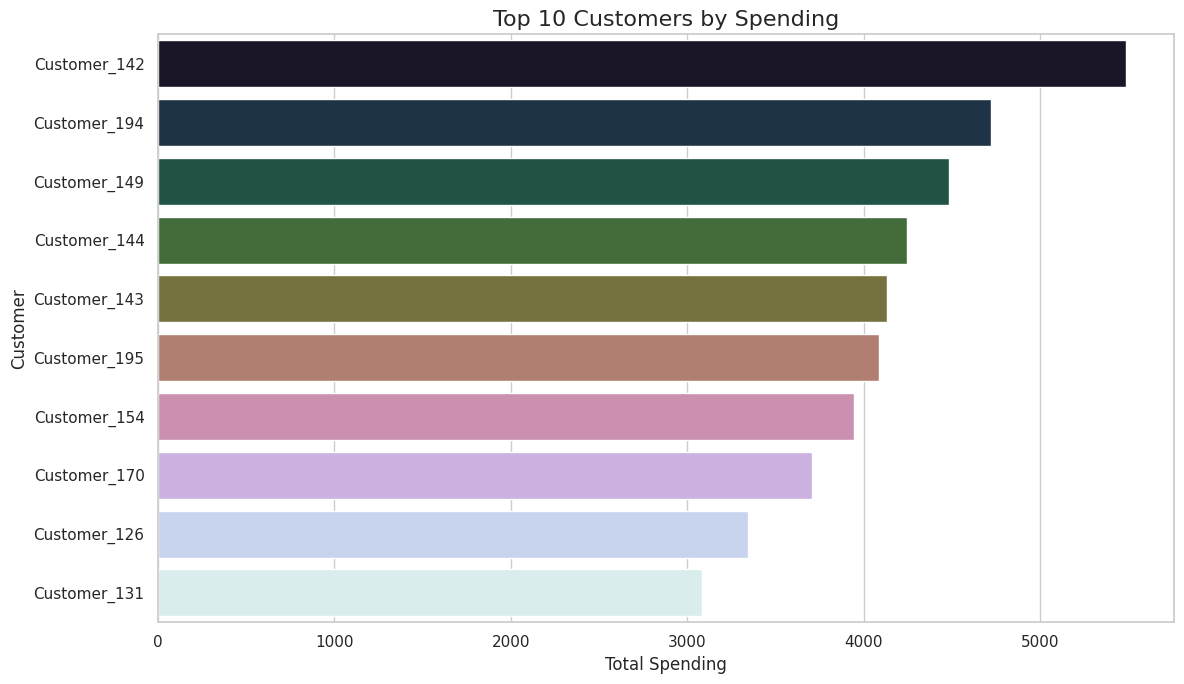

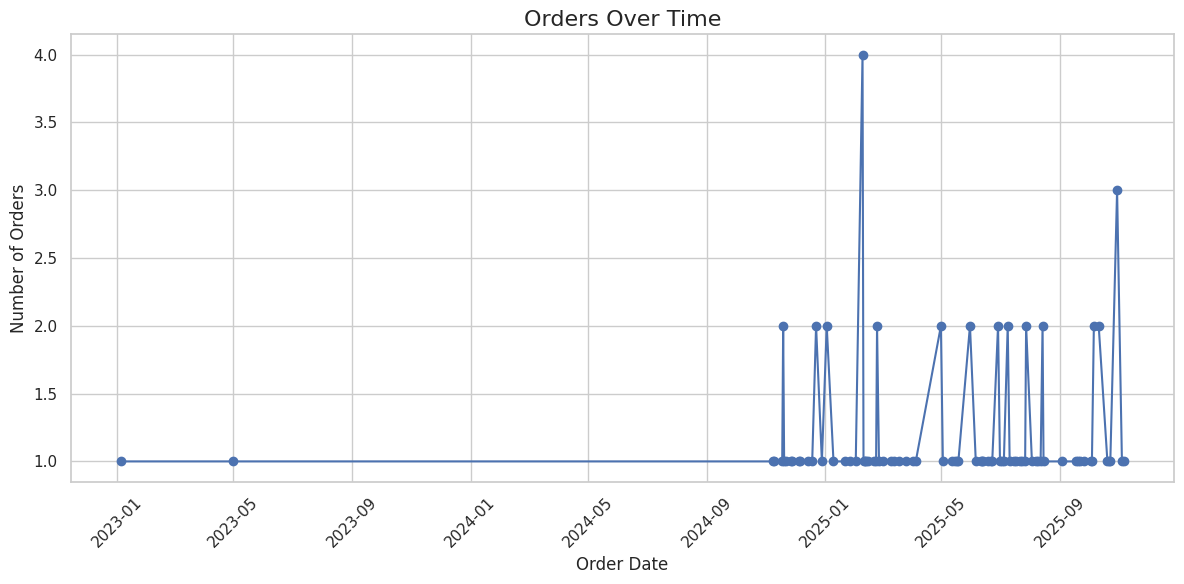

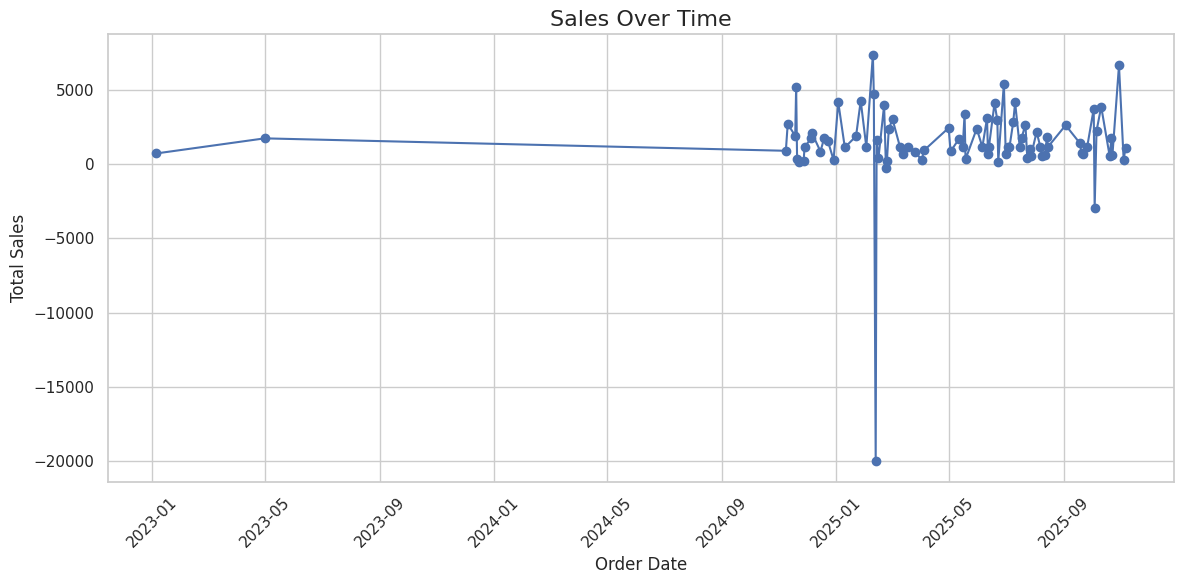


FINAL DATASET
    ID Customer_Name   Order_ID Order_Date        Product     Category  \
0  100  Customer_100  ORD-41285 2024-11-22        Blender         Home   
1  101  Customer_101  ORD-35783 2025-07-05     Smartphone  Electronics   
2  102  Customer_102  ORD-84355 2024-12-23  Tennis Racket       Sports   
3  103  Customer_103  ORD-57811 2025-03-19        Science        Books   
4  104  Customer_104  ORD-93614 2025-10-20      Biography        Books   

   Quantity    Price    Payment_Method      Status    Total  
0       3.0   38.000  Cash on Delivery     Shipped   114.00  
1       2.0  542.195            PayPal  Processing  1138.76  
2       1.0  389.050            PayPal   Delivered   389.05  
3       5.0  233.920            PayPal  Processing  1169.60  
4       1.0  552.510  Cash on Delivery  Processing   552.51  

Shape: (103, 11)

Null Values:
ID                0
Customer_Name     0
Order_ID          0
Order_Date        2
Product           0
Category          0
Quantity        

In [16]:

# ============================================================
# CUSTOMER ORDERS DATASET - VISUALIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Clean column names
# ------------------------------------------------------------

df.columns = df.columns.str.strip()

# Display columns
print("Columns:")
print(df.columns.tolist())


# ============================================================
# BASIC INFORMATION
# ============================================================

print("\n" + "="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(df.describe(include="all"))


# ============================================================
# SET VISUALIZATION STYLE
# ============================================================

sns.set_theme(style="whitegrid")


# ============================================================
# 1. ORDERS BY CATEGORY
# ============================================================

plt.figure(figsize=(10, 6))

category_count = df["Category"].value_counts()

sns.barplot(
    x=category_count.index,
    y=category_count.values,
    palette="rainbow"
)

plt.title("Number of Orders by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 2. ORDERS BY PAYMENT METHOD
# ============================================================

plt.figure(figsize=(9, 6))

payment_count = df["Payment_Method"].value_counts()

plt.pie(
    payment_count.values,
    labels=payment_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set3", len(payment_count))
)

plt.title("Payment Method Distribution", fontsize=16)
plt.show()


# ============================================================
# 3. ORDER STATUS DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

status_count = df["Status"].value_counts()

sns.barplot(
    x=status_count.index,
    y=status_count.values,
    palette="husl"
)

plt.title("Order Status Distribution", fontsize=16)
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 4. QUANTITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Quantity"],
    bins=20,
    kde=True,
    color="purple"
)

plt.title("Quantity Distribution", fontsize=16)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 5. PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Price"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Price Distribution", fontsize=16)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 6. TOTAL SALES DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Total"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Total Order Amount Distribution", fontsize=16)
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 7. CATEGORY VS TOTAL SALES
# ============================================================

category_sales = (
    df.groupby("Category")["Total"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="Spectral"
)

plt.title("Total Sales by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 8. CATEGORY VS AVERAGE PRICE
# ============================================================

category_price = (
    df.groupby("Category")["Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=category_price.index,
    y=category_price.values,
    palette="coolwarm"
)

plt.title("Average Price by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 9. PAYMENT METHOD VS TOTAL SALES
# ============================================================

payment_sales = (
    df.groupby("Payment_Method")["Total"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=payment_sales.index,
    y=payment_sales.values,
    palette="viridis"
)

plt.title("Total Sales by Payment Method", fontsize=16)
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 10. ORDER STATUS VS TOTAL SALES
# ============================================================

status_sales = (
    df.groupby("Status")["Total"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=status_sales.index,
    y=status_sales.values,
    palette="plasma"
)

plt.title("Total Sales by Order Status", fontsize=16)
plt.xlabel("Status")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 11. QUANTITY VS PRICE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Price",
    hue="Category",
    palette="tab10",
    s=80
)

plt.title("Quantity vs Price", fontsize=16)
plt.xlabel("Quantity")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


# ============================================================
# 12. QUANTITY VS TOTAL
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total",
    hue="Category",
    palette="rainbow",
    s=80
)

plt.title("Quantity vs Total Order Amount", fontsize=16)
plt.xlabel("Quantity")
plt.ylabel("Total")
plt.tight_layout()
plt.show()


# ============================================================
# 13. PRICE BOXPLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    y="Price",
    color="skyblue"
)

plt.title("Price Distribution and Outliers", fontsize=16)
plt.ylabel("Price")
plt.tight_layout()
plt.show()


# ============================================================
# 14. TOTAL BOXPLOT BY CATEGORY
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="Category",
    y="Total",
    palette="Set2"
)

plt.title("Total Amount Distribution by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 15. QUANTITY BOXPLOT BY CATEGORY
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="Category",
    y="Quantity",
    palette="Set3"
)

plt.title("Quantity Distribution by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 16. CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "Quantity",
    "Price",
    "Total"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()


# ============================================================
# 17. TOP PRODUCTS BY SALES
# ============================================================

top_products = (
    df.groupby("Product")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="magma"
)

plt.title("Top 10 Products by Total Sales", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


# ============================================================
# 18. TOP CUSTOMERS BY SPENDING
# ============================================================

top_customers = (
    df.groupby("Customer_Name")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    palette="cubehelix"
)

plt.title("Top 10 Customers by Spending", fontsize=16)
plt.xlabel("Total Spending")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()


# ============================================================
# 19. ORDERS OVER TIME
# ============================================================

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

orders_by_date = (
    df.groupby("Order_Date")
    .size()
)

plt.figure(figsize=(12, 6))

plt.plot(
    orders_by_date.index,
    orders_by_date.values,
    marker="o"
)

plt.title("Orders Over Time", fontsize=16)
plt.xlabel("Order Date")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 20. SALES OVER TIME
# ============================================================

sales_by_date = (
    df.groupby("Order_Date")["Total"]
    .sum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    sales_by_date.index,
    sales_by_date.values,
    marker="o"
)

plt.title("Sales Over Time", fontsize=16)
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# FINAL DATASET INFORMATION
# ============================================================

print("\n" + "="*60)
print("FINAL DATASET")
print("="*60)

print(df.head())

print("\nShape:", df.shape)

print("\nNull Values:")
print(df.isnull().sum())



## Features Engineering

COLUMNS
['ID', 'Customer_Name', 'Order_ID', 'Order_Date', 'Product', 'Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total']

NULL VALUES BEFORE
ID                0
Customer_Name     0
Order_ID          0
Order_Date        2
Product           0
Category          0
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

Duplicate rows:
1

FEATURE ENGINEERING COMPLETED
X Shape: (102, 13)
y Shape: (102,)

Remaining NULL VALUES:
Product             0
Category            0
Quantity            0
Price               0
Payment_Method      0
Total               0
Order_Year          0
Order_Month         0
Order_Day           0
Order_DayOfWeek     0
Is_Weekend          0
Calculated_Total    0
Price_Per_Item      0
dtype: int64

NUMERICAL FEATURES
['Quantity', 'Price', 'Total', 'Order_Year', 'Order_Month', 'Order_Day', 'Order_DayOfWeek', 'Is_Weekend', 'Calculated_Total', 'Price_Per_Item']

CATEGORICAL FEATURES
['Product', 'C

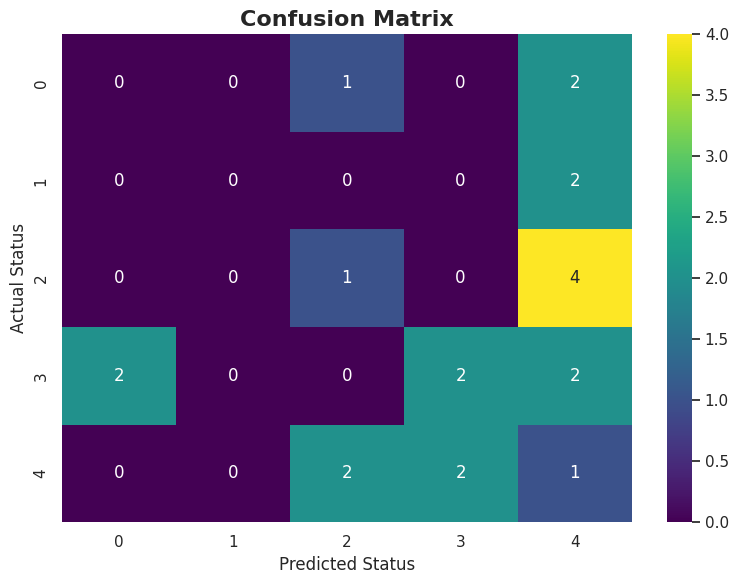


ACTUAL VS PREDICTED
        Actual   Predicted
0      Shipped  Processing
1    Cancelled  Processing
2     Returned     Shipped
3   Processing     Shipped
4    Delivered     Shipped
5     Returned     Shipped
6   Processing  Processing
7   Processing     Shipped
8      Shipped  Processing
9    Cancelled     Shipped
10    Returned    Returned
11   Delivered     Shipped
12    Returned   Cancelled
13     Shipped    Returned
14  Processing     Shipped
15     Shipped     Shipped
16   Cancelled     Shipped
17  Processing     Shipped
18    Returned    Returned
19     Shipped    Returned

TOP 20 IMPORTANT FEATURES
                                         Feature  Importance
8                      numeric__Calculated_Total    0.098580
9                        numeric__Price_Per_Item    0.095161
1                                 numeric__Price    0.091422
2                                 numeric__Total    0.087821
5                             numeric__Order_Day    0.076341
4                  

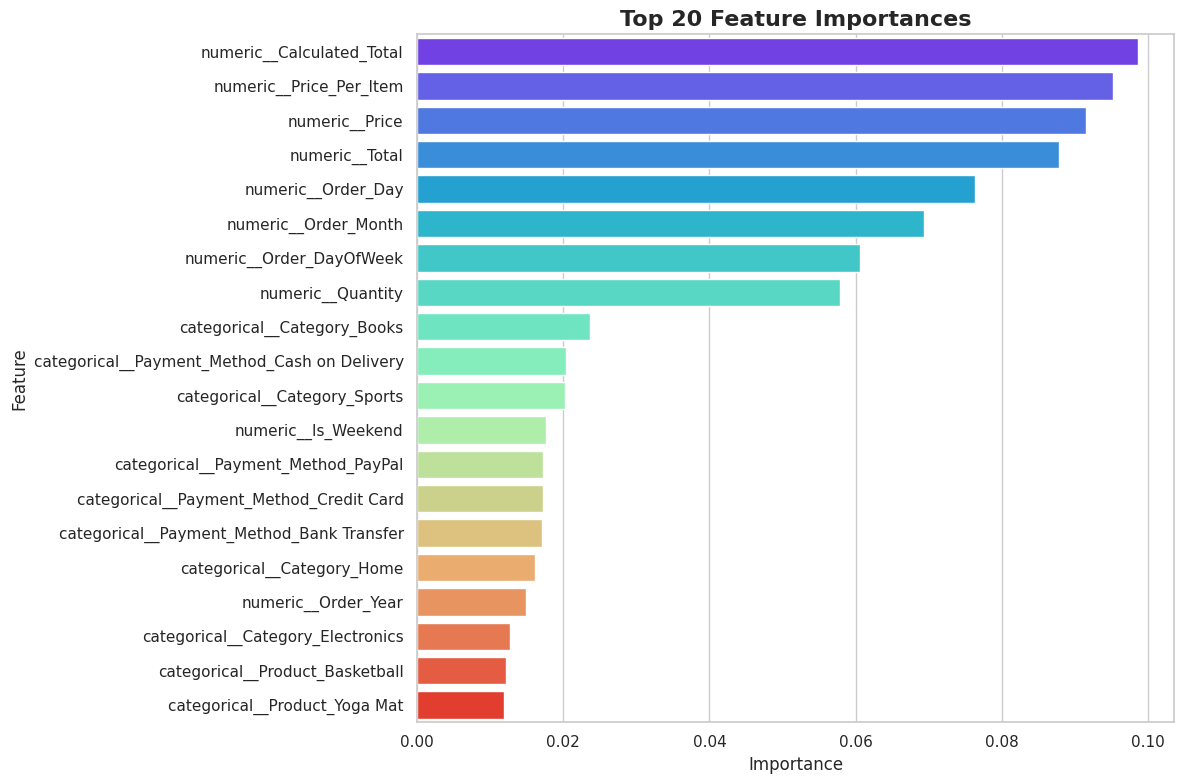


FINAL NULL CHECK
ID                  0
Customer_Name       0
Order_ID            0
Order_Date          2
Product             0
Category            0
Quantity            0
Price               0
Payment_Method      0
Status              0
Total               0
Order_Year          0
Order_Month         0
Order_Day           0
Order_DayOfWeek     0
Is_Weekend          0
Calculated_Total    0
Price_Per_Item      0
dtype: int64

FINAL MODEL SUMMARY
Dataset rows: 102
Training rows: 81
Testing rows: 21
Features: 13
Accuracy: 19.05%


In [17]:
# ============================================================
# CUSTOMER ORDERS DATASET
# FEATURE ENGINEERING
# TRAIN TEST SPLIT
# CLASSIFICATION
# RANDOM FOREST
# ACCURACY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. COPY DATA
# ============================================================

data = df.copy()


# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

data.columns = data.columns.str.strip()

print("=" * 70)
print("COLUMNS")
print("=" * 70)

print(data.columns.tolist())


# ============================================================
# 3. CHECK NULL VALUES
# ============================================================

print("\n" + "=" * 70)
print("NULL VALUES BEFORE")
print("=" * 70)

print(data.isnull().sum())


# ============================================================
# 4. CONVERT NUMERIC COLUMNS
# ============================================================

numeric_columns = [
    "Quantity",
    "Price",
    "Total"
]

for col in numeric_columns:

    if col in data.columns:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )


# ============================================================
# 5. CONVERT DATE
# ============================================================

data["Order_Date"] = pd.to_datetime(
    data["Order_Date"],
    errors="coerce"
)


# ============================================================
# 6. HANDLE CATEGORICAL NULL VALUES
# ============================================================

categorical_columns = [
    "Customer_Name",
    "Product",
    "Category",
    "Payment_Method",
    "Status"
]

for col in categorical_columns:

    if col in data.columns:

        data[col] = data[col].fillna(
            "Unknown"
        )


# ============================================================
# 7. HANDLE NUMERICAL NULL VALUES
# ============================================================

for col in numeric_columns:

    if col in data.columns:

        data[col] = data[col].fillna(
            data[col].median()
        )


# ============================================================
# 8. FEATURE ENGINEERING FROM DATE
# ============================================================

# Extract year
data["Order_Year"] = (
    data["Order_Date"].dt.year
)

# Extract month
data["Order_Month"] = (
    data["Order_Date"].dt.month
)

# Extract day
data["Order_Day"] = (
    data["Order_Date"].dt.day
)

# Extract weekday
data["Order_DayOfWeek"] = (
    data["Order_Date"].dt.dayofweek
)


# ============================================================
# 9. HANDLE DATE FEATURE NULL VALUES
# ============================================================

date_features = [
    "Order_Year",
    "Order_Month",
    "Order_Day",
    "Order_DayOfWeek"
]

for col in date_features:

    data[col] = data[col].fillna(
        data[col].median()
    )


# ============================================================
# 10. WEEKEND FEATURE
# ============================================================

data["Is_Weekend"] = (
    data["Order_DayOfWeek"] >= 5
).astype(int)


# ============================================================
# 11. CALCULATED TOTAL
# ============================================================

data["Calculated_Total"] = (
    data["Price"] *
    data["Quantity"]
)


# ============================================================
# 12. PRICE PER ITEM
# ============================================================

data["Price_Per_Item"] = (
    data["Total"] /
    data["Quantity"].replace(0, np.nan)
)


# Handle division-by-zero NaN
data["Price_Per_Item"] = (
    data["Price_Per_Item"]
    .replace([np.inf, -np.inf], np.nan)
)


data["Price_Per_Item"] = (
    data["Price_Per_Item"]
    .fillna(
        data["Price_Per_Item"].median()
    )
)


# ============================================================
# 13. REMOVE DUPLICATES
# ============================================================

print("\nDuplicate rows:")
print(data.duplicated().sum())

data = data.drop_duplicates().reset_index(
    drop=True
)


# ============================================================
# 14. REMOVE REMAINING INFINITE VALUES
# ============================================================

data = data.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 15. TARGET VARIABLE
# ============================================================

target = "Status"

y = data[target]


# ============================================================
# 16. REMOVE TARGET AND UNNECESSARY COLUMNS
# ============================================================

X = data.drop(
    columns=[
        "Status",
        "ID",
        "Order_ID",
        "Order_Date",
        "Customer_Name"
    ],
    errors="ignore"
)


# ============================================================
# 17. CHECK DATA
# ============================================================

print("\n" + "=" * 70)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 70)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nRemaining NULL VALUES:")
print(X.isnull().sum())


# ============================================================
# 18. IDENTIFY FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=[
        "int64",
        "int32",
        "float64",
        "float32"
    ]
).columns.tolist()


categorical_features = X.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()


print("\n" + "=" * 70)
print("NUMERICAL FEATURES")
print("=" * 70)

print(numeric_features)


print("\n" + "=" * 70)
print("CATEGORICAL FEATURES")
print("=" * 70)

print(categorical_features)


# ============================================================
# 19. TRAIN TEST SPLIT
# ============================================================

print("\n" + "=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)

print(y.value_counts())


class_counts = y.value_counts()


if class_counts.min() >= 2:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

else:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )


print("\nTraining data:", X_train.shape)
print("Testing data :", X_test.shape)


# ============================================================
# 20. NUMERICAL PIPELINE
# ============================================================

numeric_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]
)


# ============================================================
# 21. CATEGORICAL PIPELINE
# ============================================================

categorical_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]
)


# ============================================================
# 22. COLUMN TRANSFORMER
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )

    ]
)


# ============================================================
# 23. RANDOM FOREST
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)


# ============================================================
# 24. COMPLETE MACHINE LEARNING PIPELINE
# ============================================================

model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            random_forest
        )

    ]
)


# ============================================================
# 25. TRAIN MODEL
# ============================================================

print("\n" + "=" * 70)
print("TRAINING RANDOM FOREST")
print("=" * 70)

model.fit(
    X_train,
    y_train
)

print("Training completed successfully!")


# ============================================================
# 26. PREDICTION
# ============================================================

y_pred = model.predict(
    X_test
)


# ============================================================
# 27. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("ACCURACY")
print("=" * 70)

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Accuracy Percentage:",
    round(accuracy * 100, 2),
    "%"
)


# ============================================================
# 28. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 29. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.title(
    "Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Status"
)

plt.ylabel(
    "Actual Status"
)

plt.tight_layout()

plt.show()


# ============================================================
# 30. ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})


print("\n" + "=" * 70)
print("ACTUAL VS PREDICTED")
print("=" * 70)

print(
    comparison.head(20)
)


# ============================================================
# 31. FEATURE IMPORTANCE
# ============================================================

rf = model.named_steps[
    "classifier"
]


feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)


feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
        rf.feature_importances_

})


feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)


print("\n" + "=" * 70)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 70)

print(
    feature_importance.head(20)
)


# ============================================================
# 32. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = (
    feature_importance
    .head(20)
)


plt.figure(
    figsize=(12, 8)
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="rainbow",
    legend=False
)

plt.title(
    "Top 20 Feature Importances",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()


# ============================================================
# 33. FINAL NULL CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL NULL CHECK")
print("=" * 70)

print(
    data.isnull().sum()
)


# ============================================================
# 34. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(
    "Dataset rows:",
    len(data)
)

print(
    "Training rows:",
    len(X_train)
)

print(
    "Testing rows:",
    len(X_test)
)

print(
    "Features:",
    X.shape[1]
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)


## Thanks.......Please Upvote